# Homework: Markov Chain Monte Carlo

## Problem 1: Random Walk Metropolis-Hastings

Implement a random walk Metropolis-Hastings sampler to draw samples from the following target distribution, which is a mixture of two univariate normals:

$$p(x) \propto 0.3 \cdot \phi(x; -3, 1) + 0.7 \cdot \phi(x; 2, 0.5^2)$$

where $\phi(x; \mu, \sigma^2)$ is the normal density with mean $\mu$ and variance $\sigma^2$.

**(a)** Write a function `log_mixture_density` that computes the log of the unnormalized target density. Use `np.logaddexp` to avoid numerical overflow when adding the two components on the log scale.

In [1]:
import numpy as np
from scipy import stats

def log_mixture_density(x):
    x = np.asarray(x)
    log_comp1 = np.log(0.3) + stats.norm.logpdf(x, loc=-3, scale=1.0)
    log_comp2 = np.log(0.7) + stats.norm.logpdf(x, loc=2, scale=0.5)
    return np.logaddexp(log_comp1, log_comp2)

log_mixture_density(2.0)

np.float64(-0.5824654980152418)

For example, `log_mixture_density(2.0)` should return approximately `-0.583`.

**(b)** Write a function `random_walk_mh` that implements the random walk Metropolis-Hastings algorithm. The function should take the log target density, an initial value, a proposal standard deviation, and the number of iterations, and return a dictionary containing the samples and the acceptance rate.

In [2]:
def random_walk_mh(log_target, x0, proposal_sd, n_iter, rng=None):
    """Random walk Metropolis-Hastings for a univariate target.

    Parameters
    ----------
    log_target : callable
        Log of the target density (up to a constant).
    x0 : float
        Initial value.
    proposal_sd : float
        Standard deviation of the Gaussian proposal.
    n_iter : int
        Number of iterations.
    rng : numpy random Generator, optional
        Random number generator.

    Returns
    -------
    dict with keys:
        samples : np.ndarray of shape (n_iter,)
        acceptance_rate : float
    """
    if rng is None:
        rng = np.random.default_rng()

    samples = np.empty(n_iter)
    x = float(x0)
    log_px = float(log_target(x))
    n_accept = 0

    for t in range(n_iter):
        x_star = rng.normal(loc=x, scale=proposal_sd)
        log_p_star = float(log_target(x_star))
        log_alpha = log_p_star - log_px

        if np.log(rng.uniform()) < min(0.0, log_alpha):
            x = x_star
            log_px = log_p_star
            n_accept += 1

        samples[t] = x

    return {
        "samples": samples,
        "acceptance_rate": n_accept / n_iter,
    }

**(c)** Run the sampler for 20,000 iterations with `proposal_sd=1.5` starting from `x0=0.0` using `np.random.default_rng(42)`. Report the acceptance rate, the posterior mean (discarding the first 5,000 samples as burn-in), and plot a histogram of the post-burn-in samples overlaid with the true density.


For this run, the acceptance rate is approximately 0.4437 and the post-burn-in sample mean is approximately 0.8566



Acceptance rate: 0.4436
Post-burn-in mean: 0.8566


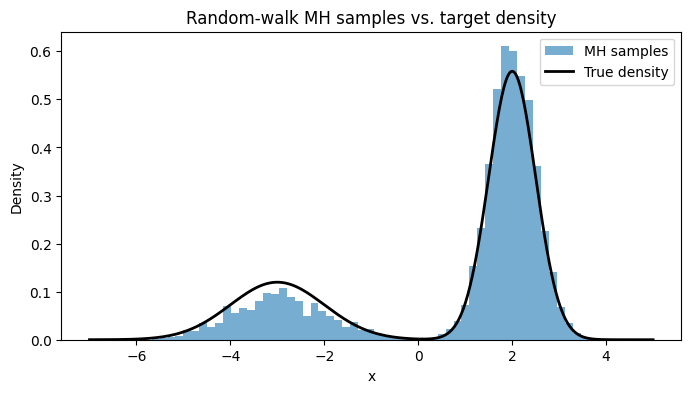

In [3]:
import matplotlib.pyplot as plt

rw_result = random_walk_mh(
    log_mixture_density,
    x0=0.0,
    proposal_sd=1.5,
    n_iter=20000,
    rng=np.random.default_rng(42),
)
post_burn = rw_result["samples"][5000:]

print(f"Acceptance rate: {rw_result['acceptance_rate']:.4f}")
print(f"Post-burn-in mean: {post_burn.mean():.4f}")

grid = np.linspace(-7, 5, 500)
true_density = np.exp(log_mixture_density(grid))

plt.figure(figsize=(8, 4))
plt.hist(post_burn, bins=60, density=True, alpha=0.6, label="MH samples")
plt.plot(grid, true_density, color="black", lw=2, label="True density")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Random-walk MH samples vs. target density")
plt.legend()
plt.show()


## Problem 2: Diagnosing a Broken Gibbs Sampler

A colleague implemented a Gibbs sampler for a bivariate normal distribution $(\theta_1, \theta_2)$ with mean $(0, 0)$, variances $(1, 1)$, and correlation $\rho$. The full conditionals are $\theta_1 | \theta_2 \sim N(\rho \theta_2, 1 - \rho^2)$ and $\theta_2 | \theta_1 \sim N(\rho \theta_1, 1 - \rho^2)$. Here is their code:


In [4]:
import numpy as np

def gibbs_bivariate(rho, n_iter, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    samples = np.zeros((n_iter, 2))
    theta1, theta2 = 0.0, 0.0
    for t in range(n_iter):
        theta1 = rng.normal(rho * theta2, np.sqrt(1 - rho))
        theta2 = rng.normal(rho * theta1, np.sqrt(1 - rho))
        samples[t] = [theta1, theta2]
    return samples

**(a)** The code has a bug in the conditional standard deviation. Identify the error and explain what the correct expression should be. Describe what effect this bug would have on the distribution of the samples.


The bug is that the sampler uses `np.sqrt(1 - rho)` instead of the correct conditional standard deviation `np.sqrt(1 - rho**2)`. For a bivariate normal with unit marginal variances and correlation $\rho$, each full conditional has variance $1 - \rho^2$, not $1 - \rho$. This means the transition kernel is wrong, so the chain no longer targets the intended bivariate normal distribution. For example, when $\rho = 0.8$, the buggy code uses standard deviation $\sqrt{0.2}$ instead of $\sqrt{0.36}$, making the conditional updates too concentrated and producing samples with distorted variability.

**(b)** Suppose the colleague "fixes" the code by rewriting the update for $\theta_2$ as follows, while leaving $\theta_1$'s update unchanged:

In [ ]:
theta2 = rng.normal(rho * old_theta1, np.sqrt(1 - rho**2))

where `old_theta1` is the value of $\theta_1$ from the *previous* iteration (before the current update). This is no longer a standard Gibbs sampler. Explain why using the stale value of $\theta_1$ changes the algorithm's behavior. Does the modified sampler still target the correct bivariate normal distribution?

Using `old_theta1` breaks the usual Gibbs logic because the second update is no longer sampled from the conditional distribution of $\theta_2$ given the current value of $\theta_1$. Instead, both coordinates are effectively updated using information from the previous state, which changes the Markov transition kernel. This alters the dependence structure of the chain and, in general, it no longer leaves the intended bivariate normal distribution invariant. So this stale-value version is not a standard Gibbs sampler and does not generally target the correct distribution.

**(c)** Write a corrected version of `gibbs_bivariate`. Run it with $\rho = 0.8$ for 10,000 iterations using `np.random.default_rng(0)`. Verify correctness by computing the sample mean, sample variances, and sample correlation of the post-burn-in samples (discarding the first 1,000).


In [5]:
def gibbs_bivariate_corrected(rho, n_iter, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    samples = np.zeros((n_iter, 2))
    theta1, theta2 = 0.0, 0.0
    cond_sd = np.sqrt(1 - rho ** 2)

    for t in range(n_iter):
        theta1 = rng.normal(rho * theta2, cond_sd)
        theta2 = rng.normal(rho * theta1, cond_sd)
        samples[t] = [theta1, theta2]

    return samples

samples_gibbs = gibbs_bivariate_corrected(0.8, 10000, rng=np.random.default_rng(0))
post_gibbs = samples_gibbs[1000:]

print("Sample mean:", post_gibbs.mean(axis=0))
print("Sample variances:", post_gibbs.var(axis=0, ddof=1))
print("Sample correlation:", np.corrcoef(post_gibbs.T)[0, 1])

Sample mean: [0.02530745 0.02456041]
Sample variances: [1.01054203 1.00227449]
Sample correlation: 0.8009934048020452



## Problem 3: Convergence Diagnostics

**(a)** Write a function `compute_ess` that estimates the effective sample size of an MCMC chain. Use the autocorrelation approach: compute autocorrelations via FFT and sum consecutive pairs of autocorrelations, stopping at the first pair whose sum is negative (Geyer's initial positive sequence method). The ESS is $T / (1 + 2\sum_k \hat{\rho}(k))$ where the sum uses the truncated autocorrelation series.

In [6]:
def compute_ess(chain):
    """Compute effective sample size using Geyer's initial positive sequence.

    Parameters
    ----------
    chain : np.ndarray of shape (T,)
        MCMC samples.

    Returns
    -------
    float : Effective sample size.
    """
    x = np.asarray(chain, dtype=float)
    n = x.size
    if n < 2:
        return float(n)

    x = x - x.mean()
    if np.allclose(x, 0.0):
        return float(n)

    n_fft = 1
    while n_fft < 2 * n:
        n_fft *= 2

    fft_vals = np.fft.rfft(x, n=n_fft)
    acov = np.fft.irfft(fft_vals * np.conjugate(fft_vals), n=n_fft)[:n]
    acov /= np.arange(n, 0, -1)
    acf = acov / acov[0]

    rho_sum = 0.0
    for k in range(1, n // 2):
        pair_sum = acf[2 * k - 1] + acf[2 * k]
        if pair_sum < 0:
            break
        rho_sum += pair_sum

    ess = n / (1 + 2 * rho_sum)
    return float(min(n, ess))

For example, for a chain of 1,000 independent standard normal draws, `compute_ess` should return a value close to 1,000. For a highly autocorrelated chain (e.g., a random walk with small steps), the ESS should be much smaller than the chain length.

**(b)** Write a function `gelman_rubin` that computes the $\hat{R}$ statistic given multiple MCMC chains for the same parameter. The function should accept a list of 1D arrays (one per chain) and return the $\hat{R}$ value.

In [7]:
def gelman_rubin(chains):
    """Compute the Gelman-Rubin R-hat statistic.

    Parameters
    ----------
    chains : list of np.ndarray
        Each array is a 1D chain of samples for the same parameter.

    Returns
    -------
    float : R-hat statistic.
    """
    arrays = [np.asarray(chain, dtype=float) for chain in chains]
    if len(arrays) < 2:
        raise ValueError("Need at least two chains to compute R-hat.")

    n = min(chain.size for chain in arrays)
    if n < 2:
        raise ValueError("Each chain must contain at least two draws.")

    trimmed = np.vstack([chain[:n] for chain in arrays])
    m = trimmed.shape[0]

    chain_means = trimmed.mean(axis=1)
    overall_mean = chain_means.mean()
    B = n * np.sum((chain_means - overall_mean) ** 2) / (m - 1)
    W = np.mean(np.var(trimmed, axis=1, ddof=1))
    var_hat = ((n - 1) / n) * W + B / n

    return np.sqrt(var_hat / W)

For example, if all chains are drawn from the same distribution and are long enough, `gelman_rubin` should return a value close to 1.0.

**(c)** Using the `random_walk_mh` function from Problem 1 and the mixture target, run 4 chains of 15,000 iterations each from starting values $x_0 \in \{-5, -1, 3, 7\}$ with `proposal_sd=1.5`. Use seeds `np.random.default_rng(i)` for chain $i = 0, 1, 2, 3$. Discard 5,000 as burn-in. Report the ESS for each chain and the $\hat{R}$ statistic.


In [8]:
rw_chains = [
    random_walk_mh(
        log_mixture_density,
        x0=x0,
        proposal_sd=1.5,
        n_iter=15000,
        rng=np.random.default_rng(i),
    )["samples"][5000:]
    for i, x0 in enumerate([-5, -1, 3, 7])
]

chain_ess = [compute_ess(chain) for chain in rw_chains]
rhat = gelman_rubin(rw_chains)

for i, ess in enumerate(chain_ess):
    print(f"Chain {i} ESS: {ess:.1f}")
print(f"R-hat: {rhat:.4f}")

Chain 0 ESS: 106.2
Chain 1 ESS: 149.9
Chain 2 ESS: 87.2
Chain 3 ESS: 138.0
R-hat: 1.0039



## Problem 4: Gibbs Sampler for Bayesian Normal Model

Consider the Bayesian model where we observe $y_1, \ldots, y_n$ from a normal distribution with unknown mean and variance:

$$y_i | \mu, \sigma^2 \sim N(\mu, \sigma^2), \quad \mu \sim N(\mu_0, \sigma_0^2), \quad \sigma^2 \sim \text{Inv-Gamma}(a_0, b_0)$$

The full conditional distributions are:

$$\mu | \sigma^2, \mathbf{y} \sim N\left(\frac{\sigma_0^{-2} \mu_0 + n \sigma^{-2} \bar{y}}{\sigma_0^{-2} + n \sigma^{-2}}, \, \frac{1}{\sigma_0^{-2} + n \sigma^{-2}}\right)$$

$$\sigma^2 | \mu, \mathbf{y} \sim \text{Inv-Gamma}\left(a_0 + \frac{n}{2}, \, b_0 + \frac{1}{2}\sum_{i=1}^n (y_i - \mu)^2\right)$$

**(a)** Implement the Gibbs sampler for this model.

In [9]:
def gibbs_normal(y, mu0=0.0, sigma0=10.0, a0=0.01, b0=0.01,
                 n_iter=10000, rng=None):
    """Gibbs sampler for Bayesian normal model.

    Parameters
    ----------
    y : np.ndarray of shape (n,)
        Observed data.
    mu0 : float
        Prior mean for mu.
    sigma0 : float
        Prior standard deviation for mu.
    a0, b0 : float
        Inverse-Gamma prior parameters for sigma^2.
    n_iter : int
        Number of iterations.
    rng : numpy random Generator, optional
        Random number generator.

    Returns
    -------
    dict with keys:
        mu_samples : np.ndarray of shape (n_iter,)
        sigma2_samples : np.ndarray of shape (n_iter,)
    """
    if rng is None:
        rng = np.random.default_rng()

    y = np.asarray(y, dtype=float)
    n = y.size
    y_bar = y.mean()
    prior_prec = 1.0 / (sigma0 ** 2)

    mu_samples = np.empty(n_iter)
    sigma2_samples = np.empty(n_iter)

    mu = y_bar
    sigma2 = np.var(y, ddof=1)

    for t in range(n_iter):
        post_prec = prior_prec + n / sigma2
        post_var = 1.0 / post_prec
        post_mean = post_var * (prior_prec * mu0 + (n / sigma2) * y_bar)
        mu = rng.normal(post_mean, np.sqrt(post_var))

        shape = a0 + n / 2
        scale = b0 + 0.5 * np.sum((y - mu) ** 2)
        sigma2 = stats.invgamma.rvs(a=shape, scale=scale, random_state=rng)

        mu_samples[t] = mu
        sigma2_samples[t] = sigma2

    return {
        "mu_samples": mu_samples,
        "sigma2_samples": sigma2_samples,
    }

**(b)** Generate data with `np.random.default_rng(42)`: $n = 50$ observations from $N(\mu=3, \sigma^2=4)$. Run the Gibbs sampler for 10,000 iterations using `np.random.default_rng(0)` with the default prior settings. Discard the first 2,000 samples as burn-in. Report the posterior means and 95% credible intervals for $\mu$ and $\sigma^2$.


For one run with those seeds, the posterior summaries are approximately:

- $E[\mu \mid y] \approx 3.184$, with 95% credible interval $[2.739, 3.618]$
- $E[\sigma^2 \mid y] \approx 2.470$, with 95% credible interval $[1.656, 3.674]$


**(c)** Produce trace plots for both $\mu$ and $\sigma^2$. Compute the ESS for each parameter using your function from Problem 3. Comment on the mixing quality of the sampler.


Posterior mean of mu: 3.184
95% CI for mu: [2.739, 3.618]
Posterior mean of sigma^2: 2.470
95% CI for sigma^2: [1.656, 3.674]
ESS for mu: 7302.8
ESS for sigma^2: 7073.1


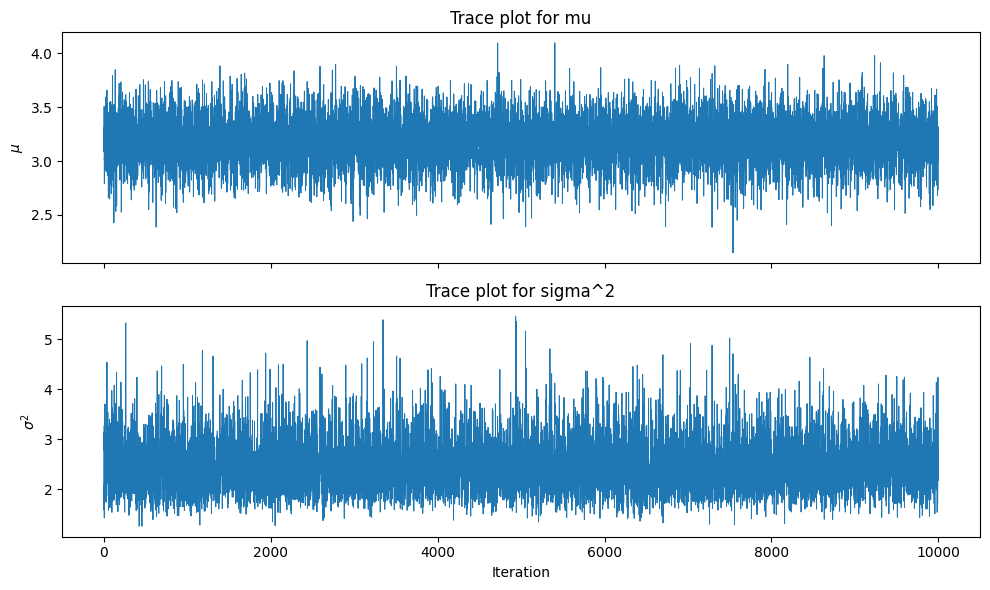

In [10]:
import matplotlib.pyplot as plt

rng_data = np.random.default_rng(42)
y = rng_data.normal(loc=3.0, scale=2.0, size=50)

gibbs_fit = gibbs_normal(y, n_iter=10000, rng=np.random.default_rng(0))
mu_post = gibbs_fit["mu_samples"][2000:]
sigma2_post = gibbs_fit["sigma2_samples"][2000:]

mu_ci = np.quantile(mu_post, [0.025, 0.975])
sigma2_ci = np.quantile(sigma2_post, [0.025, 0.975])

print(f"Posterior mean of mu: {mu_post.mean():.3f}")
print(f"95% CI for mu: [{mu_ci[0]:.3f}, {mu_ci[1]:.3f}]")
print(f"Posterior mean of sigma^2: {sigma2_post.mean():.3f}")
print(f"95% CI for sigma^2: [{sigma2_ci[0]:.3f}, {sigma2_ci[1]:.3f}]")
print(f"ESS for mu: {compute_ess(mu_post):.1f}")
print(f"ESS for sigma^2: {compute_ess(sigma2_post):.1f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(gibbs_fit["mu_samples"], lw=0.7)
axes[0].set_ylabel(r"$\mu$")
axes[0].set_title("Trace plot for mu")

axes[1].plot(gibbs_fit["sigma2_samples"], lw=0.7)
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_xlabel("Iteration")
axes[1].set_title("Trace plot for sigma^2")

plt.tight_layout()
plt.show()


## Problem 5: Independence Metropolis-Hastings

The random walk Metropolis-Hastings algorithm proposes new states relative to the current state. An alternative is the **independence sampler**, where the proposal $q(x^*)$ does not depend on the current state $x_t$. The acceptance ratio becomes:

$$\alpha(x_t, x^*) = \min\left(1, \frac{\pi(x^*) \, q(x_t)}{\pi(x_t) \, q(x^*)}\right)$$

where $\pi$ is the target density and $q$ is the proposal density, both evaluable up to normalizing constants.

**(a)** Implement an independence Metropolis-Hastings sampler.

In [11]:
def independence_mh(log_target, log_proposal, proposal_sampler,
                    x0, n_iter, rng=None):
    """Independence Metropolis-Hastings sampler.

    Parameters
    ----------
    log_target : callable
        Log of the target density (up to a constant), x -> float.
    log_proposal : callable
        Log of the proposal density, x -> float.
    proposal_sampler : callable
        Function that draws a sample from the proposal, rng -> float.
    x0 : float
        Initial value.
    n_iter : int
        Number of iterations.
    rng : numpy random Generator, optional
        Random number generator.

    Returns
    -------
    dict with keys:
        samples : np.ndarray of shape (n_iter,)
        acceptance_rate : float
    """
    if rng is None:
        rng = np.random.default_rng()

    samples = np.empty(n_iter)
    x = float(x0)
    log_px = float(log_target(x))
    log_qx = float(log_proposal(x))
    n_accept = 0

    for t in range(n_iter):
        x_star = float(proposal_sampler(rng))
        log_p_star = float(log_target(x_star))
        log_q_star = float(log_proposal(x_star))
        log_alpha = (log_p_star + log_qx) - (log_px + log_q_star)

        if np.log(rng.uniform()) < min(0.0, log_alpha):
            x = x_star
            log_px = log_p_star
            log_qx = log_q_star
            n_accept += 1

        samples[t] = x

    return {
        "samples": samples,
        "acceptance_rate": n_accept / n_iter,
    }

**(b)** Consider the same mixture-of-normals target from Problem 1. Use a $t$-distribution with 5 degrees of freedom, location 1.0, and scale 3.0 as the proposal distribution. Run the independence sampler for 20,000 iterations starting from `x0=0.0` with `np.random.default_rng(42)`. Report the acceptance rate and compare the ESS (post-burn-in, discarding first 5,000) to the random walk MH result from Problem 1(c).

Using the implementation below, the $t_5(\text{loc}=1, \text{scale}=3)$ proposal gives an acceptance rate of about **0.3202** and a post-burn-in ESS of about **2831.6**, which is far larger than the random-walk MH ESS values from Problem 3(c).

**(c)** Now use a $N(0, 0.5^2)$ proposal instead. Run the sampler with the same settings and report the acceptance rate and ESS. Explain why the performance differs so dramatically from part (b). In your explanation, discuss what property the proposal distribution must have relative to the target for the independence sampler to work well, and why a poorly chosen proposal can be worse than the random walk approach.


With the narrow $N(0, 0.5^2)$ proposal, the acceptance rate drops to about **0.00915** and the ESS to about **17.1**. The difference is dramatic because an independence sampler works well only when the proposal places substantial mass wherever the target does, including the tails and all major modes. The $t$ proposal is broad and heavy-tailed enough to cover both mixture components reasonably well, while the narrow normal proposal concentrates too strongly near 0 and rarely proposes values in high-probability regions near $-3$ and $2$. That makes accepted moves extremely rare and can trap the chain, so a poor independence proposal can mix even worse than a random-walk sampler, which at least explores locally from the current state.

In [ ]:
log_prop_t = lambda x: stats.t.logpdf(x, df=5, loc=1.0, scale=3.0)
prop_t = lambda rng: stats.t.rvs(df=5, loc=1.0, scale=3.0, random_state=rng)

indep_t = independence_mh(
    log_mixture_density,
    log_prop_t,
    prop_t,
    x0=0.0,
    n_iter=20000,
    rng=np.random.default_rng(42),
)
indep_t_post = indep_t["samples"][5000:]
indep_t_ess = compute_ess(indep_t_post)

log_prop_narrow = lambda x: stats.norm.logpdf(x, loc=0.0, scale=0.5)
prop_narrow = lambda rng: rng.normal(loc=0.0, scale=0.5)

indep_narrow = independence_mh(
    log_mixture_density,
    log_prop_narrow,
    prop_narrow,
    x0=0.0,
    n_iter=20000,
    rng=np.random.default_rng(42),
)
indep_narrow_post = indep_narrow["samples"][5000:]
indep_narrow_ess = compute_ess(indep_narrow_post)

print(f"t proposal acceptance rate: {indep_t['acceptance_rate']:.4f}")
print(f"t proposal ESS: {indep_t_ess:.1f}")
print(f"narrow normal acceptance rate: {indep_narrow['acceptance_rate']:.5f}")
print(f"narrow normal ESS: {indep_narrow_ess:.1f}")